## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| **Elemento** | **Descripción** |
|---|---|
| **Percepción (S)** | Ingreso mensual, monto solicitado y existencia de historial moroso. |
| **Acciones (A)** | Aprobar, aprobar con condiciones o rechazar la solicitud. |
| **Entorno (E)** | Sistema bancario encargado de recibir y evaluar las solicitudes de crédito. |
| **Medida de desempeño (P)** | Tomar decisiones coherentes y reducir el riesgo de otorgar créditos inadecuados. |

### Justificación de las reglas

Las reglas consideran la relación entre el monto solicitado y el ingreso mensual para evaluar la capacidad de pago del cliente. También se considera el historial moroso, porque permite identificar un mayor riesgo de incumplimiento. De esta manera, el agente puede aprobar, aprobar con condiciones o rechazar una solicitud según las condiciones establecidas.

In [2]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if relacion <= 3 and not tiene_historial_moroso:
        accion = "Aprobar"
        motivo = "La relación entre el monto solicitado y el ingreso es adecuada y no tiene historial moroso."
    
    elif relacion <= 3 and tiene_historial_moroso:
        accion = "Aprobar con condiciones"
        motivo = "La relación es adecuada, pero el cliente tiene historial moroso."
    
    elif relacion > 3 and not tiene_historial_moroso:
        accion = "Aprobar con condiciones"
        motivo = "El monto solicitado es alto respecto al ingreso, aunque no tiene historial moroso."
    
    else:
        accion = "Rechazar"
        motivo = "El monto solicitado es alto respecto al ingreso y el cliente tiene historial moroso."

    return accion, motivo

### Simulación y pruebas


In [3]:
# Prueba 1: relación menor que 3 y sin historial moroso
print(agente_credito(2000, 4000, False))

# Prueba 2: relación igual a 3 (caso de frontera)
print(agente_credito(2000, 6000, False))

# Prueba 3: relación menor que 3 con historial moroso
print(agente_credito(3000, 6000, True))

# Prueba 4: relación mayor que 3 sin historial moroso
print(agente_credito(2000, 8000, False))

# Prueba 5: relación mayor que 3 con historial moroso
print(agente_credito(2000, 8000, True))

# Prueba 6: relación igual a 3 con historial moroso
print(agente_credito(5000, 15000, True))

('Aprobar', 'La relación entre el monto solicitado y el ingreso es adecuada y no tiene historial moroso.')
('Aprobar', 'La relación entre el monto solicitado y el ingreso es adecuada y no tiene historial moroso.')
('Aprobar con condiciones', 'La relación es adecuada, pero el cliente tiene historial moroso.')
('Aprobar con condiciones', 'El monto solicitado es alto respecto al ingreso, aunque no tiene historial moroso.')
('Rechazar', 'El monto solicitado es alto respecto al ingreso y el cliente tiene historial moroso.')
('Aprobar con condiciones', 'La relación es adecuada, pero el cliente tiene historial moroso.')


### Visualización


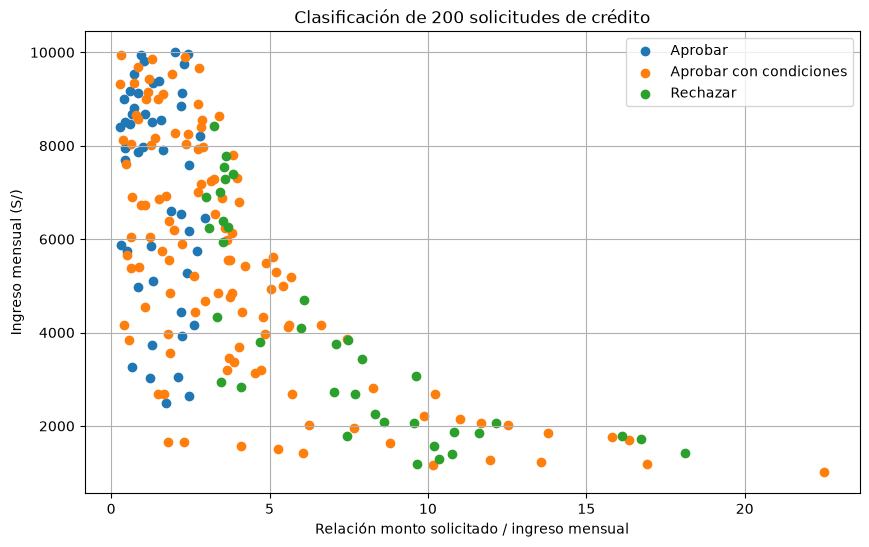

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

solicitudes = []

for _ in range(200):
    ingreso = np.random.randint(1000, 10001)
    monto = np.random.randint(1000, 30001)
    historial = np.random.choice([True, False])

    accion, motivo = agente_credito(ingreso, monto, historial)
    relacion = monto / ingreso

    solicitudes.append((ingreso, monto, historial, relacion, accion))

# Separar los datos según la acción
aprobadas = [s for s in solicitudes if s[4] == "Aprobar"]
condiciones = [s for s in solicitudes if s[4] == "Aprobar con condiciones"]
rechazadas = [s for s in solicitudes if s[4] == "Rechazar"]

# Crear la gráfica
plt.figure(figsize=(10, 6))

plt.scatter(
    [s[3] for s in aprobadas],
    [s[0] for s in aprobadas],
    label="Aprobar"
)

plt.scatter(
    [s[3] for s in condiciones],
    [s[0] for s in condiciones],
    label="Aprobar con condiciones"
)

plt.scatter(
    [s[3] for s in rechazadas],
    [s[0] for s in rechazadas],
    label="Rechazar"
)

plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Clasificación de 200 solicitudes de crédito")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de las pruebas

Las pruebas muestran que el agente toma una decisión según la relación entre el monto solicitado y el ingreso mensual, además del historial moroso. Cuando la relación es adecuada y no existe morosidad, la solicitud es aprobada. Si existe una condición de riesgo, se aprueba con condiciones, mientras que una relación alta acompañada de historial moroso provoca el rechazo.


Autor:Miguel, Palomino Cardenas